# **Analisis Sentimen dan Jaringan Sosial pada Media Sosial X untuk Menilai Persepsi Publik terhadap Program Stunting di Indonesia**

## Rumusan Masalah
Rumusan masalah yang menjadi fokus penelitian ini adalah sebagai berikut:

1. Bagaimana hasil sentimen publik terhadap program stunting 2024 di media sosial X menggunakan VADER Lexicon dan BERT?
2. Bagaimana perbandingan tingkat akurasi algoritma machine learning GBT, SVM, dan XGBoost dalam mengklasifikasikan sentimen publik terhadap program stunting?
3. Bagaimana posisi dan peran aktor dalam jaringan sosial yang terbentuk dari percakapan mengenai program stunting di media sosial X?

## 2. Import Library dan Data

In [1]:
!pip install nltk
!pip install Sastrawi
!pip install swifter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16505 sha256=5814e3b6d884fea4f4573ed0b1d4ffb90e80b85eb730a9c1a360eade00b49925
  Stored in directory: /root/.cache/pip/wheels/ef/7f/bd/9bed48f078f3ee1fa75e0b29b6e0335ce1cb03a38d3443b3a3
Successfully built swifter


In [2]:
# Core Libraries
import os # Interact with the operating system
import re # Regular expressions for text processing [https://regex101.com/]
import random # Random number generators and sequence shuffling
import string # Operations on strings, e.g., punctuation
import json

# Data Manipulation and Processing
import numpy as np # Linear algebra and numerical computations
import pandas as pd # Data processing, e.g., reading/writing CSV files and manipulating DataFrames
pd.set_option("display.max_columns", None) # Ensure all columns are displayed

# Visualization Libraries
import matplotlib.pyplot as plt # Plotting and data visualization
import seaborn as sns # Statistical data visualization
from plotly import graph_objs as go # Advanced interactive visualizations
import plotly.express as px # High-level API for Plotly visualizations
import plotly.figure_factory as ff # Additional Plotly visualization tools

# Natural Language Processing (NLP) Libraries
import nltk # Natural Language Toolkit for NLP tasks
from nltk.corpus import stopwords # List of stopwords for text preprocessing
from nltk.tokenize import word_tokenize # Tokenization of text into words
from nltk.stem import WordNetLemmatizer, PorterStemmer # Stemming and Lemmatization
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory # Indonesian language stemming

# Text Feature Extraction
from sklearn.feature_extraction.text import (
    TfidfTransformer, # Transform term frequency matrix to TF-IDF
    CountVectorizer, # Convert text into a bag-of-words representation
    TfidfVectorizer # Transform text into TF-IDF representation
)

# Machine Learning and Preprocessing
from sklearn.model_selection import train_test_split # Split data into train and test sets
from sklearn.preprocessing import StandardScaler, FunctionTransformer # Data scaling and transformation

# Evaluation Metrics for Machine Learning Models
from sklearn.metrics import (
    precision_score, # Ratio of true positives to total predicted positives
    recall_score, # Ratio of true positives to total actual positives
    f1_score, # Harmonic mean of precision and recall
    classification_report, # Summary of precision, recall, F1 score, and support
    accuracy_score # Proportion of correct predictions
)

# Miscellaneous Utilities
from tqdm import tqdm # Progress bar for monitoring loops and tasks
from collections import Counter # Count elements in a collection

# Word Clouds and Image Processing
from PIL import Image # Image processing library
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator # Generate and customize word clouds

# Gensim for Topic Modeling
# import gensim # Library for topic modeling and vector space modeling


In [3]:
nltk.download(['stopwords', 'punkt', 'wordnet'])
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:

import os
import pandas as pd

# Tentukan path folder yang berisi file CSV
folder_path = '/content/drive/MyDrive/Laporan_NLP/NLP/Data/'

# Membuat list untuk menyimpan DataFrame
dataframes = []

# Loop melalui semua file dalam folder
for file_name in os.listdir(folder_path):
    # Cek apakah file berformat .csv
    if file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        # Membaca file CSV dan menambahkannya ke list
        df = pd.read_csv(file_path)
        dataframes.append(df)

# Menggabungkan semua DataFrame
db_gab = pd.concat(dataframes, ignore_index=True)

# Pilih kolom yang diinginkan
db_merge = db_gab.copy()
db_merge = db_merge[["username","in_reply_to_screen_name", "full_text"]]

# Opsional: Mengecek dimensi hasil penggabungan
print(f"Dimensi hasil gabungan: {db_merge.shape}")

Dimensi hasil gabungan: (8527, 3)


In [6]:
pd.set_option('display.max_colwidth', None)

# Display the first 5 rows (or adjust as needed) of the merged DataFrame
# Filter the rows where 'in_reply_to_screen_name' is not NaN
filtered_data = db_merge[db_merge['in_reply_to_screen_name'].notna()]

# Display the first 5 rows of the filtered data
filtered_data.sample(5)


,username,in_reply_to_screen_name,full_text
4520,krispychasiew,meowingsun_,@meowlngsvn_ Dari stunting ke sobat muscle
1602,indienas,indienas,@nabiylarisfa Seperti stunting yang pencegahannya bukan sejak dalam kandungan tapi sejak ibunya masih kecil karakter pun demikian. Jadi aku setuju mereka tidak memilih peluang ya karena sudah terkondisi untuk begitu sejak dari zaman nenek-kakeknya. Struktural sistem whatnots.
7990,jurgnsapi,inspuire,@inspuire Kalo kurus jadi kucing stunting
3129,target_mama,LinCuang,@LinCuang @pn7l7h Anda layak makan gratis karena stunting
3554,_Schatz2,somem8say_,@armandoggggg tolol lo. iq rendah dikasi nyawa ya begini hasil stunting 20 taun yang lalu sini maklo gua kasi gizi yang cukup biar kalo punya anak kaga stunting


In [7]:
db_gab.columns

Index(['conversation_id_str', 'created_at', 'favorite_count', 'full_text',
       'id_str', 'image_url', 'in_reply_to_screen_name', 'lang', 'location',
       'quote_count', 'reply_count', 'retweet_count', 'tweet_url',
       'user_id_str', 'username'],
      dtype='object')

In [8]:
# Menampilkan 5 baris pertama hasil gabungan
db_merge.head()

,username,in_reply_to_screen_name,full_text
0,oravine_,oravine_,cuma yang nggak mengalami PTSD yang digunain buat perhitungan IQ. Ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting.
1,sebayu_94FM,NaN,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR) Kota Tegal bersama Kelurahan Tegalsari serta Puskesmas Tegal Barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting. Selengkapnya di https://t.co/VBeJ8wCaE2 #infotegal #kotategal #pemkottegal https://t.co/zgVjt1Hc78
2,raquellstep,ajengrizkyJ,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya. itu jg faktor tidak langsung. makanya kan aku blg cmiiw
3,ajengrizkyJ,raquellstep,@raquellstep @bibahjenner @tanyakanrl Belajar yg bener besok balik lagi.. stunting itu karena gizi anak sejak kehamilan sampe usia tertentu tidak terpenuhi.. bukan masalah ibunya tidak tinggi.. kocak banget ortunya pendek disebut stunting..
4,Kanwil_Bali,NaN,DUKUNG PENCEGAHAN STUNTING POSYANDU IBU DAN BALITA BERDIKARI 04 DIRESMIKAN DI LAPAS PEREMPUAN KEROBOKAN . Tayangan selengkapnya kunjungi: https://t.co/tQVXizO2G1 . @Kemenkumham_RI . #KumhamSemakinPASTI #KanwilKemenkumhamBali #PosyanduIbudanBalita https://t.co/kQP4KhRRxr


In [9]:
db_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8527 entries, 0 to 8526
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   username                 8527 non-null   object
 1   in_reply_to_screen_name  3235 non-null   object
 2   full_text                8527 non-null   object
dtypes: object(3)
memory usage: 200.0+ KB


## Data Preprocessing and Labeling

### 1.Remove Duplicates

Tujuan: Menghapus baris duplikat pada dataset untuk menghindari bias dalam analisis.

In [10]:
!pip install ace-tools


In [11]:
# import ace_tools as tools


In [12]:
# Menampilkan data yang memiliki duplikasi berdasarkan 'full_text'
duplicates_data = db_merge[db_merge.duplicated(subset=['full_text'], keep=False)]
duplicates_data.head(10)


,username,in_reply_to_screen_name,full_text
19,OlaStunting,jay0__7,@jay0__7 Nawa
20,PolsekAntapani_,NaN,Bhabinkamtibmas Polsek Antapani Polrestabes Bandung Aiptu Eko Kosasih bersama dengan Babinsa Koramil 1810/ARC menghadiri dan monitoring kegiatan Pencegahan dan penanganan stunting di Kelurahan Sindangjaya.(04/10/2024) https://t.co/aQQ8sjkYn8
21,BPOMPontianak,BPOMPontianak,Tim KPD kader dan komunitas dapat berbagi wawasan ini sebagai wujud pemberdayaaan aktif masyarakat Desa Semerangkai menerapkan keamanan pangan lebih baik. Keamanan pangan mendukung upaya bersama mencegah stunting. https://t.co/7VFRUvBETh
22,BPOMPontianak,BPOMPontianak,sekolah ritel IRTP pangan siap saji serta stunting dan pencegahannya. Pendalaman materi bersama ini memperkuat pemahaman dan praktik keamanan pangan untuk mencegah stunting di Desa Semerangkai. Kegiatan edukasi juga diperkaya melalui simulasi permainan paket https://t.co/zRRMjeoJoC
23,jpnncom,NaN,Pelatihan ini diharapkan dapat menjadi model yang dapat diterapkan di berbagai daerah lain di Indonesia #Pelatihan #Stunting https://t.co/zrXy25vs5r
24,JalaludinAbu,NaN,Babinsa Oeltua Koramil 1604-01/Kupang Serka Severius Tali bersama Kepala Desa Oeltua dan perangkat desa lainnya melaksanakan Rapat Rembug Stunting tingkat Desa Oeltua Tahun Anggaran 2025. Kegiatan ini berlangsung di Kantor Desa Oeltua Kecamatan Taebenu Kabupaten Kupang. https://t.co/WogAWJo70o
25,ATRspydoos,msaid_didu,@msaid_didu Gusti allah tidak tidur ya pasti lah. Mending makan nasi bungkus dulu biar ga stunting
26,AGajebooo,NaN,Wkwkwk menuju indonesia stunting
27,dramselette,NaN,LAH WAKTU ITU GW DAPET KONSUM DARI FPP AYAMNYA STUNTING
28,manemismem,polcanisme,@polcanisme kak tutor kalo skpmnya dighosting doswal dari smter 1 gmn


In [13]:
sample_data = db_merge.loc[[559, 938]]
sample_data

,username,in_reply_to_screen_name,full_text
559,nashrajumaani,nashrajumaani,Jika berjalan dengan baik program makanan bergizi gratis misalnya tak hanya mengatasi stunting tapi juga dapat menjadi sarana pemberdayaan bisnis lokal peningkatan peran koperasi dan peningkatan peran petani lokal pungkasnya.
938,SB8cekatan,SB8cekatan,Stunting merupakan masalah gizi kronis yang dapat menghambat pertumbuhan dan perkembangan anak. Oleh karena itu pencegahan stunting perlu dilakukan sejak dini.


In [14]:
# Menghitung jumlah duplikat sebelum penghapusan
duplicates_before = db_merge.duplicated(subset=['full_text']).sum()
print(f"Jumlah duplikat sebelum penghapusan: {duplicates_before}")

# Menghapus duplikat
db_merge = db_merge.drop_duplicates(subset=['full_text']).reset_index(drop=True)

# Menghitung jumlah duplikat setelah penghapusan
duplicates_after = db_merge.duplicated(subset=['full_text']).sum()
print(f"Jumlah duplikat setelah penghapusan: {duplicates_after}")


Jumlah duplikat sebelum penghapusan: 456
Jumlah duplikat setelah penghapusan: 0


In [15]:
db_merge.head()

,username,in_reply_to_screen_name,full_text
0,oravine_,oravine_,cuma yang nggak mengalami PTSD yang digunain buat perhitungan IQ. Ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting.
1,sebayu_94FM,NaN,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR) Kota Tegal bersama Kelurahan Tegalsari serta Puskesmas Tegal Barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting. Selengkapnya di https://t.co/VBeJ8wCaE2 #infotegal #kotategal #pemkottegal https://t.co/zgVjt1Hc78
2,raquellstep,ajengrizkyJ,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya. itu jg faktor tidak langsung. makanya kan aku blg cmiiw
3,ajengrizkyJ,raquellstep,@raquellstep @bibahjenner @tanyakanrl Belajar yg bener besok balik lagi.. stunting itu karena gizi anak sejak kehamilan sampe usia tertentu tidak terpenuhi.. bukan masalah ibunya tidak tinggi.. kocak banget ortunya pendek disebut stunting..
4,Kanwil_Bali,NaN,DUKUNG PENCEGAHAN STUNTING POSYANDU IBU DAN BALITA BERDIKARI 04 DIRESMIKAN DI LAPAS PEREMPUAN KEROBOKAN . Tayangan selengkapnya kunjungi: https://t.co/tQVXizO2G1 . @Kemenkumham_RI . #KumhamSemakinPASTI #KanwilKemenkumhamBali #PosyanduIbudanBalita https://t.co/kQP4KhRRxr


### 2.Text Cleaning Process

Tujuan: Membersihkan teks dari karakter yang tidak relevan seperti tag, URL, angka, dan tanda baca.

In [16]:
import re
import unicodedata

def cleaning(content):
    # Mengubah ke huruf kecil
    content = content.lower()
    # Menghapus karakter non-ASCII
    content = unicodedata.normalize('NFKD', content).encode('ascii', 'ignore').decode('utf-8', 'ignore')
    # Menghapus URL
    content = re.sub(r'(?i)\b((?:https?://|www\d{0,3}[.]|[a-z0-9.\-]+[.][a-z]{2,4}/)(?:[^\s()<>]+|\(([^\s()<>]+|(\([^\s()<>]+\)))*\))+(?:\(([^\s()<>]+|(\([^\s()<>]+\)))*\)|[^\s`!()\[\]{};:\'".,<>?«»“”‘’]))', '', content)
    # Menghapus tanda baca
    content = re.sub(r'[^\w]|_',' ', content)
    # Menghapus digit dari string
    content = re.sub("\S*\d\S*", "", content).strip()
    # Menghapus angka atau digit
    content = re.sub(r"\b\d+\b", " ", content)
    # Menghapus spasi tambahan
    content = re.sub('[\s]+', ' ', content)
    # Menghilangkan spasi awal/akhir
    content = content.strip(' ')

    return content

# Terapkan fungsi ke kolom 'full_text' untuk membuat kolom 'Cleaned_Text'
db_merge['Cleaned_Text'] = db_merge['full_text'].apply(cleaning)


In [17]:
db_merge[['full_text', 'Cleaned_Text']].head()

,full_text,Cleaned_Text
0,cuma yang nggak mengalami PTSD yang digunain buat perhitungan IQ. Ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting.,cuma yang nggak mengalami ptsd yang digunain buat perhitungan iq ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting
1,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR) Kota Tegal bersama Kelurahan Tegalsari serta Puskesmas Tegal Barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting. Selengkapnya di https://t.co/VBeJ8wCaE2 #infotegal #kotategal #pemkottegal https://t.co/zgVjt1Hc78,dinas pekerjaan umum dan penataan ruang dpupr kota tegal bersama kelurahan tegalsari serta puskesmas tegal barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting selengkapnya di infotegal kotategal pemkottegal
2,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya. itu jg faktor tidak langsung. makanya kan aku blg cmiiw,ajengrizkyj bibahjenner tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya itu jg faktor tidak langsung makanya kan aku blg cmiiw
3,@raquellstep @bibahjenner @tanyakanrl Belajar yg bener besok balik lagi.. stunting itu karena gizi anak sejak kehamilan sampe usia tertentu tidak terpenuhi.. bukan masalah ibunya tidak tinggi.. kocak banget ortunya pendek disebut stunting..,raquellstep bibahjenner tanyakanrl belajar yg bener besok balik lagi stunting itu karena gizi anak sejak kehamilan sampe usia tertentu tidak terpenuhi bukan masalah ibunya tidak tinggi kocak banget ortunya pendek disebut stunting
4,DUKUNG PENCEGAHAN STUNTING POSYANDU IBU DAN BALITA BERDIKARI 04 DIRESMIKAN DI LAPAS PEREMPUAN KEROBOKAN . Tayangan selengkapnya kunjungi: https://t.co/tQVXizO2G1 . @Kemenkumham_RI . #KumhamSemakinPASTI #KanwilKemenkumhamBali #PosyanduIbudanBalita https://t.co/kQP4KhRRxr,dukung pencegahan stunting posyandu ibu dan balita berdikari diresmikan di lapas perempuan kerobokan tayangan selengkapnya kunjungi kemenkumham ri kumhamsemakinpasti kanwilkemenkumhambali posyanduibudanbalita


### 3.Tokenizing

In [18]:
def tokenize_content(content):
    return word_tokenize(content)

# Tokenisasi sebelum formalisasi
db_merge['Tokenized_Text'] = db_merge['Cleaned_Text'].apply(word_tokenize)

In [19]:
db_merge.head()

,username,in_reply_to_screen_name,full_text,Cleaned_Text,Tokenized_Text
0,oravine_,oravine_,cuma yang nggak mengalami PTSD yang digunain buat perhitungan IQ. Ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting.,cuma yang nggak mengalami ptsd yang digunain buat perhitungan iq ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting,"[cuma, yang, nggak, mengalami, ptsd, yang, digunain, buat, perhitungan, iq, ini, salah, satu, contoh, yang, nunjukin, sampel, yang, digunain, di, sini, berasal, dari, wilayah, tertentu, dengan, kondisi, sosial, tertentu, termasuk, disebutin, daerah, yang, terdampak, defisiensi, yodium, cacingan, atau, stunting]"
1,sebayu_94FM,NaN,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR) Kota Tegal bersama Kelurahan Tegalsari serta Puskesmas Tegal Barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting. Selengkapnya di https://t.co/VBeJ8wCaE2 #infotegal #kotategal #pemkottegal https://t.co/zgVjt1Hc78,dinas pekerjaan umum dan penataan ruang dpupr kota tegal bersama kelurahan tegalsari serta puskesmas tegal barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting selengkapnya di infotegal kotategal pemkottegal,"[dinas, pekerjaan, umum, dan, penataan, ruang, dpupr, kota, tegal, bersama, kelurahan, tegalsari, serta, puskesmas, tegal, barat, bersinergi, dan, berkolaborasi, melalui, inovasinya, dalam, menangani, kasus, stunting, selengkapnya, di, infotegal, kotategal, pemkottegal]"
2,raquellstep,ajengrizkyJ,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya. itu jg faktor tidak langsung. makanya kan aku blg cmiiw,ajengrizkyj bibahjenner tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya itu jg faktor tidak langsung makanya kan aku blg cmiiw,"[ajengrizkyj, bibahjenner, tanyakanrl, kak, maaf, bgt, ya, kalo, salah, tp, yg, aku, sebut, jg, bukan, ibunya, yg, stunting, tp, nnt, si, anaknya, itu, jg, faktor, tidak, langsung, makanya, kan, aku, blg, cmiiw]"
3,ajengrizkyJ,raquellstep,@raquellstep @bibahjenner @tanyakanrl Belajar yg bener besok balik lagi.. stunting itu karena gizi anak sejak kehamilan sampe usia tertentu tidak terpenuhi.. bukan masalah ibunya tidak tinggi.. kocak banget ortunya pendek disebut stunting..,raquellstep bibahjenner tanyakanrl belajar yg bener besok balik lagi stunting itu karena gizi anak sejak kehamilan sampe usia tertentu tidak terpenuhi bukan masalah ibunya tidak tinggi kocak banget ortunya pendek disebut stunting,"[raquellstep, bibahjenner, tanyakanrl, belajar, yg, bener, besok, balik, lagi, stunting, itu, karena, gizi, anak, sejak, kehamilan, sampe, usia, tertentu, tidak, terpenuhi, bukan, masalah, ibunya, tidak, tinggi, kocak, banget, ortunya, pendek, disebut, stunting]"
4,Kanwil_Bali,NaN,DUKUNG PENCEGAHAN STUNTING POSYANDU IBU DAN BALITA BERDIKARI 04 DIRESMIKAN DI LAPAS PEREMPUAN KEROBOKAN . Tayangan selengkapnya kunjungi: https://t.co/tQVXizO2G1 . @Kemenkumham_RI . #KumhamSemakinPASTI #KanwilKemenkumhamBali #PosyanduIbudanBalita https://t.co/kQP4KhRRxr,dukung pencegahan stunting posyandu ibu dan balita berdikari diresmikan di lapas perempuan kerobokan tayangan selengkapnya kunjungi kemenkumham ri kumhamsemakinpasti kanwilkemenkumhambali posyanduibudanbalita,"[dukung, pencegahan, stunting, posyandu, ibu, dan, balita, berdikari, diresmikan, di, lapas, perempuan, kerobokan, tayangan, selengkapnya, kunjungi, kemenkumham, ri, kumhamsemakinpasti, kanwilkemenkumhambali, posyanduibudanbalita]"


### 4.Formulasi atau Slang Word Normalization

Tahap formalisasi dilakukan untuk pengubah penggunaan kata tidak baku menjadi baku sesuai dengan KBBI. Proses akan menggunakan file dataset slangwords yang berisi kata slang yang nanti akan diubah menjadi baku. Tahap ini dibantu dengan library RegEx.

Tanggal  |  Durasi

6 Feb 2025  |  33 s

In [20]:
# Fungsi untuk memuat dan mengonversi kata-kata slang menjadi kata baku
def convertToSlangword(ulasan):
    # Tambahkan kata slang yang belum ada di dalam file
    additional_slang_words = {
        "banget": "sangat", "baper": "bawa perasaan", "bawel": "banyak bicara",
        "bayar": "membayar", "bbm": "bahan bakar minyak", "bgs": "bagus",
        "bodo": "bodoh", "bucin": "budak cinta",
        "caper": "cari perhatian", "cengengesan": "tertawa", "cemong": "cacat",
        "cimeng": "ganja", "cupz": "culun", "cowok": "laki-laki",
        "cwe": "cewek", "emang": "memang", "enggak": "tidak",
        "flu": "pilek", "garing": "hambar",
        "gile": "gila", "gitu": "seperti itu", "goblok": "bodoh",
        "gomel": "bajingan", "gpp": "gak papa", "gradak": "tiba-tiba", "hadeuh": "duh",
        "hanya": "cuma", "horr": "horor", "infonya": "informasinya", "jgn": "jangan",
        "juga": "ya", "kaget": "terkejut",
        "kocak": "lucu", "kudu": "harus", "kuy": "ayo",
        "libur": "cuti", "lucu": "comel", "makasih": "terima kasih",
        "malah": "justru", "mau": "ingin", "mbok": "mama",
        "misuh": "marah", "ngeri": "takut", "nggak": "tidak",
        "ngomong": "bicara", "ngga": "tidak",
        "out": "keluar", "pasti": "yakin",
        "tapi": "tetapi", "tau": "tahu", "tdk": "tidak",
        "telat": "terlambat", "terimakasih": "terima kasih", "top": "terbaik",
        "tuch": "itu", "yuk": "ayo", "waspada": "hati-hati", "wkwk": "haha",
        "wow": "wah", "yah": "iya", "yakin": "percaya", "yaa": "iya", "yukk": "ayo",
        "zaman": "masa", "zaman sekarang": "masa kini", "zaman dulu": "masa lalu"
    }

    # Menyertakan path yang benar untuk file slang words
    slang_file_path = "/content/drive/MyDrive/Laporan_NLP/NLP/combined_slang_words.txt"

    # Membaca file JSON yang berisi kamus slang
    with open(slang_file_path, "r") as file:
        kamusSlang = json.load(file)

    # Menambahkan slang baru ke kamus
    kamusSlang.update(additional_slang_words)

    # Membuat pola RegEx untuk mendeteksi kata slang di dalam teks
    pattern = re.compile(r'\b(' + '|'.join(kamusSlang.keys()) + r')\b')

    # Ubah setiap kata slang yang ditemukan dalam ulasan menjadi kata baku
    content = []
    for kata in ulasan:
        filterSlang = pattern.sub(lambda x: kamusSlang[x.group()], kata)
        content.append(filterSlang.lower())  # Mengonversi ke huruf kecil agar konsisten

    return content

# Terapkan formalisasi (mengubah kata slang menjadi baku) setelah tokenisasi
db_merge['Formalized_Text'] = db_merge['Tokenized_Text'].apply(convertToSlangword)

db_merge.head()


,username,in_reply_to_screen_name,full_text,Cleaned_Text,Tokenized_Text,Formalized_Text
0,oravine_,oravine_,cuma yang nggak mengalami PTSD yang digunain buat perhitungan IQ. Ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting.,cuma yang nggak mengalami ptsd yang digunain buat perhitungan iq ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting,"[cuma, yang, nggak, mengalami, ptsd, yang, digunain, buat, perhitungan, iq, ini, salah, satu, contoh, yang, nunjukin, sampel, yang, digunain, di, sini, berasal, dari, wilayah, tertentu, dengan, kondisi, sosial, tertentu, termasuk, disebutin, daerah, yang, terdampak, defisiensi, yodium, cacingan, atau, stunting]","[cuma, yang, tidak, mengalami, ptsd, yang, digunain, buat, perhitungan, iq, ini, salah, satu, contoh, yang, nunjukin, sampel, yang, digunain, di, sini, berasal, dari, wilayah, tertentu, dengan, kondisi, sosial, tertentu, termasuk, disebutin, daerah, yang, terdampak, defisiensi, yodium, cacingan, atau, stunting]"
1,sebayu_94FM,NaN,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR) Kota Tegal bersama Kelurahan Tegalsari serta Puskesmas Tegal Barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting. Selengkapnya di https://t.co/VBeJ8wCaE2 #infotegal #kotategal #pemkottegal https://t.co/zgVjt1Hc78,dinas pekerjaan umum dan penataan ruang dpupr kota tegal bersama kelurahan tegalsari serta puskesmas tegal barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting selengkapnya di infotegal kotategal pemkottegal,"[dinas, pekerjaan, umum, dan, penataan, ruang, dpupr, kota, tegal, bersama, kelurahan, tegalsari, serta, puskesmas, tegal, barat, bersinergi, dan, berkolaborasi, melalui, inovasinya, dalam, menangani, kasus, stunting, selengkapnya, di, infotegal, kotategal, pemkottegal]","[dinas, pekerjaan, umum, dan, penataan, ruang, dpupr, kota, tegal, bersama, kelurahan, tegalsari, serta, puskesmas, tegal, barat, bersinergi, dan, berkolaborasi, melalui, inovasinya, dalam, menangani, kasus, stunting, selengkapnya, di, infotegal, kotategal, pemkottegal]"
2,raquellstep,ajengrizkyJ,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya. itu jg faktor tidak langsung. makanya kan aku blg cmiiw,ajengrizkyj bibahjenner tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya itu jg faktor tidak langsung makanya kan aku blg cmiiw,"[ajengrizkyj, bibahjenner, tanyakanrl, kak, maaf, bgt, ya, kalo, salah, tp, yg, aku, sebut, jg, bukan, ibunya, yg, stunting, tp, nnt, si, anaknya, itu, jg, faktor, tidak, langsung, makanya, kan, aku, blg, cmiiw]","[ajengrizkyj, bibahjenner, tanyakanrl, kak, maaf, banget, iya, kalau, salah, tapi, yang, aku, sebut, juga, bukan, ibunya, yang, stunting, tapi, nnt, si, anaknya, itu, juga, faktor, tidak, langsung, makanya, kan, aku, bilang, correct me if i'm wrong]"
3,ajengrizkyJ,raquellstep,@raquellstep @bibahjenner @tanyakanrl Belajar yg bener besok balik lagi.. stunting itu karena gizi anak sejak kehamilan sampe usia tertentu tidak terpenuhi.. bukan masalah ibunya tidak tinggi.. kocak banget ortunya pendek disebut stunting..,raquellstep bibahjenner tanyakanrl belajar yg bener besok balik lagi stunting itu karena gizi anak sejak kehamilan sampe usia tertentu tidak terpenuhi bukan masalah ibunya tidak tinggi kocak banget ortunya pendek disebut stunting,"[raquellstep, bibahjenner, tanyakanrl, belajar, yg, bener, besok, balik, lagi, stunting, itu, karena, gizi, anak, sejak, kehamilan, sampe, usia, tertentu, tidak, terpenuhi, bukan, masalah, ibunya, tidak, tinggi, kocak, banget, ortunya, pendek, disebut, stunting]"

In [21]:
db_merge.head()

,username,in_reply_to_screen_name,full_text,Cleaned_Text,Tokenized_Text,Formalized_Text
0,oravine_,oravine_,cuma yang nggak mengalami PTSD yang digunain buat perhitungan IQ. Ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting.,cuma yang nggak mengalami ptsd yang digunain buat perhitungan iq ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting,"[cuma, yang, nggak, mengalami, ptsd, yang, digunain, buat, perhitungan, iq, ini, salah, satu, contoh, yang, nunjukin, sampel, yang, digunain, di, sini, berasal, dari, wilayah, tertentu, dengan, kondisi, sosial, tertentu, termasuk, disebutin, daerah, yang, terdampak, defisiensi, yodium, cacingan, atau, stunting]","[cuma, yang, tidak, mengalami, ptsd, yang, digunain, buat, perhitungan, iq, ini, salah, satu, contoh, yang, nunjukin, sampel, yang, digunain, di, sini, berasal, dari, wilayah, tertentu, dengan, kondisi, sosial, tertentu, termasuk, disebutin, daerah, yang, terdampak, defisiensi, yodium, cacingan, atau, stunting]"
1,sebayu_94FM,NaN,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR) Kota Tegal bersama Kelurahan Tegalsari serta Puskesmas Tegal Barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting. Selengkapnya di https://t.co/VBeJ8wCaE2 #infotegal #kotategal #pemkottegal https://t.co/zgVjt1Hc78,dinas pekerjaan umum dan penataan ruang dpupr kota tegal bersama kelurahan tegalsari serta puskesmas tegal barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting selengkapnya di infotegal kotategal pemkottegal,"[dinas, pekerjaan, umum, dan, penataan, ruang, dpupr, kota, tegal, bersama, kelurahan, tegalsari, serta, puskesmas, tegal, barat, bersinergi, dan, berkolaborasi, melalui, inovasinya, dalam, menangani, kasus, stunting, selengkapnya, di, infotegal, kotategal, pemkottegal]","[dinas, pekerjaan, umum, dan, penataan, ruang, dpupr, kota, tegal, bersama, kelurahan, tegalsari, serta, puskesmas, tegal, barat, bersinergi, dan, berkolaborasi, melalui, inovasinya, dalam, menangani, kasus, stunting, selengkapnya, di, infotegal, kotategal, pemkottegal]"
2,raquellstep,ajengrizkyJ,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya. itu jg faktor tidak langsung. makanya kan aku blg cmiiw,ajengrizkyj bibahjenner tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya itu jg faktor tidak langsung makanya kan aku blg cmiiw,"[ajengrizkyj, bibahjenner, tanyakanrl, kak, maaf, bgt, ya, kalo, salah, tp, yg, aku, sebut, jg, bukan, ibunya, yg, stunting, tp, nnt, si, anaknya, itu, jg, faktor, tidak, langsung, makanya, kan, aku, blg, cmiiw]","[ajengrizkyj, bibahjenner, tanyakanrl, kak, maaf, banget, iya, kalau, salah, tapi, yang, aku, sebut, juga, bukan, ibunya, yang, stunting, tapi, nnt, si, anaknya, itu, juga, faktor, tidak, langsung, makanya, kan, aku, bilang, correct me if i'm wrong]"
3,ajengrizkyJ,raquellstep,@raquellstep @bibahjenner @tanyakanrl Belajar yg bener besok balik lagi.. stunting itu karena gizi anak sejak kehamilan sampe usia tertentu tidak terpenuhi.. bukan masalah ibunya tidak tinggi.. kocak banget ortunya pendek disebut stunting..,raquellstep bibahjenner tanyakanrl belajar yg bener besok balik lagi stunting itu karena gizi anak sejak kehamilan sampe usia tertentu tidak terpenuhi bukan masalah ibunya tidak tinggi kocak banget ortunya pendek disebut stunting,"[raquellstep, bibahjenner, tanyakanrl, belajar, yg, bener, besok, balik, lagi, stunting, itu, karena, gizi, anak, sejak, kehamilan, sampe, usia, tertentu, tidak, terpenuhi, bukan, masalah, ibunya, tidak, tinggi, kocak, banget, ortunya, pendek, disebut, stunting]"

### 6.Stopword Removal
Tujuan: Menghapus kata-kata umum yang tidak memiliki makna penting (stopwords).

Tanggal  |  Durasi

6 Feb 2025  |  10 s

In [22]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Unduh stopwords jika belum
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [23]:
# Ambil stopwords bahasa Indonesia dari NLTK
stop_words = set(stopwords.words('indonesian'))  # Menggunakan set untuk efisiensi

# Cek jumlah stopwords sebelum ditambah
print("Jumlah Stopwords Sebelum Update:", len(stop_words))

# Tambahkan kata-kata stopwords khusus (termasuk dari additional_stopwords dan custom stopwords)
stop_words.update({
    "yg", "dg", "rt", "dgn", "ny", "d", "ga", "klo", "kalo", "amp", "biar",
    "bikin", "bilang", "gak", "g", "krn", "nya", "sih", "si", "tau", "tdk",
    "utk", "ya", "jd", "jgn", "sdh", "aja", "n", "t", "nyg", "hehe", "pen",
    "u", "loh", "yah", "gmn", "ttp", "dk", "kn", "dlm", "kl", "b", "dan",
    "yang", "di", "dengan", "dari", "kamu", "jadi", "ke", "itu", "ini",
    "saja", "juga", "lagi", "ada", "untuk", "eh", "lho", "makanya", "biang",
    "asik", "maksudnya", "apakah", "bagaimana", "seperti", "gitu", "oh",
    "aku", "lo", "tuh", "pasti", "kalau", "sama", "kapan", "mereka", "kalian",
    "cuma", "selalu", "yuk", "nah", "misalnya", "gimana", "soalnya", "bisa",
    "pengen", "coba", "eh", "yaudah", "sih", "gitu", "serius", "pasti", "belum",
    "menurut", "tau", "tuh", "loh", "sudah", "gak", "cuma", "udah", "mungkin",
    "ayo", "apalagi", "tapi", "jadi", "nggak", "ngomong", "gitu", "itu",
    "emang", "kenapa", "iya", "juga", "pasti", "pernah", "dulu", "kebanyakan",
    "sekarang", "dong", "bener", "kalo", "lalu", "begitu", "sama", "aja", "terus",
    "kesini", "langsung", "lah", "buat", "mengapa", "lebih", "lebih baik", "kan",
    "katanya", "nggak", "bilang", "anggap", "kalau", "apa", "bagi", "deh",
    "dalam", "bagian", "kita", "ini", "untuk", "senang", "mengatakan", "semua",
    "gitu", "lah", "nah", "kami", "aja", "ah", "ak", "ambilin", "ap2", "apaan",
    "apesh", "baiklah", "basah", "bdg", "beberapa", "beliin", "beut", "biasa",
    "bicara", "biologi", "bgs", "biang", "buru", "bawa", "bolak", "bolos", "bubur",
    "cadangan", "ceper", "ciluk", "clol", "cok", "curhat", "dan", "deh", "depan",
    "dll", "dong", "dulu", "dikirim", "dlm", "ga", "gak", "gak banget", "gak ya",
    "gemes", "gokil", "gues", "gini", "gitu", "gg", "goblok", "gue", "haduh", "hati-hati",
    "heeh", "harus", "hati", "hidup", "hilang", "honor", "huh", "itu", "jangan", "jelek",
    "jadi", "juga", "jgn", "ka", "kabur", "kami", "kampret", "kan", "kapan", "kata",
    "kebanyakan", "kebanyakan", "kemana", "kemaren", "kemerdekaan", "kenapa", "kecuali",
    "keluar", "kl", "kk", "komputer", "koq", "kya", "lebih", "lalu", "lama", "lagi",
    "lapor", "lebaran", "langsung", "lah", "layak", "lewat", "main", "makanan", "makasih",
    "malaikat", "maksudnya", "makan", "mampir", "manusia", "mau", "misalnya",
    "mood", "ngabers", "ngelamun", "ngga", "ngomongin", "ngomongnya", "ngomong",
    "no", "oke", "otw", "pake", "pas", "pasti", "penjelasan", "pengetahuan", "pesan",
    "pulang", "ragu", "ringan", "saja", "salam", "sakit", "sekarang", "seperti", "semua",
    "sering", "semua", "semuanya", "seperti", "sial", "simpan", "simpel", "tidak", "tiko",
    "tolo", "tuh", "udah", "up", "wah", "ya", "yaudah", "yg", "ygs", "yg",
    "yuk", "zz", "sinyal"
})

# Cek jumlah stopwords setelah update
print("Jumlah Stopwords Setelah Update:", len(stop_words))

# Tampilkan beberapa stopwords tambahan sebagai contoh
print("Beberapa Stopwords Tambahan:", list(stop_words)[10:])

# Fungsi untuk menghapus stopwords
def removeStopword(text):
    if not isinstance(text, str):
        text = str(text)

    # Bersihkan tanda baca
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenisasi kata
    word_tokens = word_tokenize(text)

    # Hilangkan spasi berlebih + lowercase + cek stopword
    filtered_sentence = [w.strip().lower() for w in word_tokens if w.strip().lower() not in stop_words]
    return ' '.join(filtered_sentence)


# Terapkan fungsi ke kolom dataset
db_merge['Stopword_Removed_Text'] = db_merge['Formalized_Text'].apply(removeStopword)


Jumlah Stopwords Sebelum Update: 757
Jumlah Stopwords Setelah Update: 921
Beberapa Stopwords Tambahan: ['ygs', 'sebaiknya', 'sudahkah', 'beberapa', 'amp', 'berjumlah', 'sebab', 'ngomong', 'zz', 'sepantasnya', 'hampir', 'anda', 'ingat-ingat', 'dimaksudnya', 'menanti-nanti', 'sudah', 'buru', 'dimaksudkannya', 'naik', 'utk', 'ke', 'tentulah', 'seenaknya', 'entahlah', 'menunjuknya', 'sebagian', 'tahu', 'meskipun', 'menurut', 'ibaratkan', 'ciluk', 'melihat', 'setengah', 'layak', 'ikut', 'jelasnya', 'mengenai', 'pihaknya', 'diantaranya', 'apabila', 'bisa', 'up', 'nah', 'adapun', 'kebetulan', 'dilakukan', 'curhat', 'iya', 'perlu', 'didapat', 'pertama', 'sana', 'tampaknya', 'nya', 'kalaulah', 'sekarang', 'tidakkah', 'seorang', 'keluar', 'dimaksud', 'terutama', 'terkira', 'loh', 'diantara', 'lain', 'gokil', 'sesudahnya', 'dikirim', 'jelek', 'biasanya', 'akankah', 'terbanyak', 'main', 'cukuplah', 'seperti', 'sdh', 'nyatanya', 'kalian', 'bgs', 'mungkin', 'mulailah', 'diinginkan', 'dekat', 'diguna

In [24]:
db_merge[['Formalized_Text', 'Stopword_Removed_Text']].head()

,Formalized_Text,Stopword_Removed_Text
0,"[cuma, yang, tidak, mengalami, ptsd, yang, digunain, buat, perhitungan, iq, ini, salah, satu, contoh, yang, nunjukin, sampel, yang, digunain, di, sini, berasal, dari, wilayah, tertentu, dengan, kondisi, sosial, tertentu, termasuk, disebutin, daerah, yang, terdampak, defisiensi, yodium, cacingan, atau, stunting]",mengalami ptsd digunain perhitungan iq salah contoh nunjukin sampel digunain berasal wilayah kondisi sosial disebutin daerah terdampak defisiensi yodium cacingan stunting
1,"[dinas, pekerjaan, umum, dan, penataan, ruang, dpupr, kota, tegal, bersama, kelurahan, tegalsari, serta, puskesmas, tegal, barat, bersinergi, dan, berkolaborasi, melalui, inovasinya, dalam, menangani, kasus, stunting, selengkapnya, di, infotegal, kotategal, pemkottegal]",dinas pekerjaan penataan ruang dpupr kota tegal kelurahan tegalsari puskesmas tegal barat bersinergi berkolaborasi inovasinya menangani stunting selengkapnya infotegal kotategal pemkottegal
2,"[ajengrizkyj, bibahjenner, tanyakanrl, kak, maaf, banget, iya, kalau, salah, tapi, yang, aku, sebut, juga, bukan, ibunya, yang, stunting, tapi, nnt, si, anaknya, itu, juga, faktor, tidak, langsung, makanya, kan, aku, bilang, correct me if i'm wrong]",ajengrizkyj bibahjenner tanyakanrl kak maaf banget salah ibunya stunting nnt anaknya faktor correct me if im wrong
3,"[raquellstep, bibahjenner, tanyakanrl, belajar, yang, benar, besok, balik, lagi, stunting, itu, karena, gizi, anak, sejak, kehamilan, sampai, usia, tertentu, tidak, terpenuhi, bukan, masalah, ibunya, tidak, tinggi, lucu, sangat, ortunya, pendek, disebut, stunting]",raquellstep bibahjenner tanyakanrl belajar besok stunting gizi anak kehamilan usia terpenuhi ibunya lucu ortunya pendek stunting
4,"[dukung, pencegahan, stunting, posyandu, ibu, dan, balita, berdiri di atas kaki sendiri, diresmikan, di, lembaga pemasyarakatan, perempuan, kerobokan, tayangan, selengkapnya, kunjungi, kemenkumham, ri, kumhamsemakinpasti, kanwilkemenkumhambali, posyanduibudanbalita]",dukung pencegahan stunting posyandu balita berdiri kaki diresmikan lembaga pemasyarakatan perempuan kerobokan tayangan selengkapnya kunjungi kemenkumham ri kumhamsemakinpasti kanwilkemenkumhambali posyanduibudanbalita


In [46]:
#Save hasil remove stopword
db_merge[['username', 'full_text', 'Stopword_Removed_Text']].to_csv(
    'hasil_stopword_removed.csv',
    index=False,
    encoding='utf-8'
)
print("Tersimpan: hasil_stopword_removed.csv")


Tersimpan: hasil_stopword_removed.csv


### 7.Stemming
Tujuan: Mengubah kata menjadi bentuk dasar. Stemming menggunakan Sastrawi.

Tanggal  |  Durasi

6 Feb 2025  |  28m 53s

In [25]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import swifter

# Inisialisasi Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Fungsi Stemming lebih efisien
def stemmingText(text):
    if not isinstance(text, str):
        return ""
    return stemmer.stem(text)  # langsung stem seluruh kalimat

# Terapkan stemming dengan swifter
db_merge['Stemmed_Text'] = db_merge['Stopword_Removed_Text'].swifter.apply(stemmingText)

# Tokenisasi setelah stemming (opsional)
db_merge['Stemmed_Text'] = db_merge['Stemmed_Text'].apply(lambda x: word_tokenize(x) if isinstance(x, str) else [])

# Tampilkan hasil
db_merge[['Formalized_Text', 'Stopword_Removed_Text', 'Stemmed_Text']].head()


Pandas Apply:   0%|          | 0/8071 [00:00<?, ?it/s]

,Formalized_Text,Stopword_Removed_Text,Stemmed_Text
0,"[cuma, yang, tidak, mengalami, ptsd, yang, digunain, buat, perhitungan, iq, ini, salah, satu, contoh, yang, nunjukin, sampel, yang, digunain, di, sini, berasal, dari, wilayah, tertentu, dengan, kondisi, sosial, tertentu, termasuk, disebutin, daerah, yang, terdampak, defisiensi, yodium, cacingan, atau, stunting]",mengalami ptsd digunain perhitungan iq salah contoh nunjukin sampel digunain berasal wilayah kondisi sosial disebutin daerah terdampak defisiensi yodium cacingan stunting,"[alami, ptsd, digunain, hitung, iq, salah, contoh, nunjukin, sampel, digunain, asal, wilayah, kondisi, sosial, disebutin, daerah, dampak, defisiensi, yodium, cacing, stunting]"
1,"[dinas, pekerjaan, umum, dan, penataan, ruang, dpupr, kota, tegal, bersama, kelurahan, tegalsari, serta, puskesmas, tegal, barat, bersinergi, dan, berkolaborasi, melalui, inovasinya, dalam, menangani, kasus, stunting, selengkapnya, di, infotegal, kotategal, pemkottegal]",dinas pekerjaan penataan ruang dpupr kota tegal kelurahan tegalsari puskesmas tegal barat bersinergi berkolaborasi inovasinya menangani stunting selengkapnya infotegal kotategal pemkottegal,"[dinas, kerja, tata, ruang, dpupr, kota, tegal, lurah, tegalsari, puskesmas, tegal, barat, sinergi, kolaborasi, inovasi, tangan, stunting, lengkap, infotegal, kotategal, pemkottegal]"
2,"[ajengrizkyj, bibahjenner, tanyakanrl, kak, maaf, banget, iya, kalau, salah, tapi, yang, aku, sebut, juga, bukan, ibunya, yang, stunting, tapi, nnt, si, anaknya, itu, juga, faktor, tidak, langsung, makanya, kan, aku, bilang, correct me if i'm wrong]",ajengrizkyj bibahjenner tanyakanrl kak maaf banget salah ibunya stunting nnt anaknya faktor correct me if im wrong,"[ajengrizkyj, bibahjenner, tanyakanrl, kak, maaf, banget, salah, ibu, stunting, nnt, anak, faktor, correct, me, if, im, wrong]"
3,"[raquellstep, bibahjenner, tanyakanrl, belajar, yang, benar, besok, balik, lagi, stunting, itu, karena, gizi, anak, sejak, kehamilan, sampai, usia, tertentu, tidak, terpenuhi, bukan, masalah, ibunya, tidak, tinggi, lucu, sangat, ortunya, pendek, disebut, stunting]",raquellstep bibahjenner tanyakanrl belajar besok stunting gizi anak kehamilan usia terpenuhi ibunya lucu ortunya pendek stunting,"[raquellstep, bibahjenner, tanyakanrl, ajar, besok, stunting, gizi, anak, hamil, usia, penuh, ibu, lucu, ortunya, pendek, stunting]"
4,"[dukung, pencegahan, stunting, posyandu, ibu, dan, balita, berdiri di atas kaki sendiri, diresmikan, di, lembaga pemasyarakatan, perempuan, kerobokan, tayangan, selengkapnya, kunjungi, kemenkumham, ri, kumhamsemakinpasti, kanwilkemenkumhambali, posyanduibudanbalita]",dukung pencegahan stunting posyandu balita berdiri kaki diresmikan lembaga pemasyarakatan perempuan kerobokan tayangan selengkapnya kunjungi kemenkumham ri kumhamsemakinpasti kanwilkemenkumhambali posyanduibudanbalita,"[dukung, cegah, stunting, posyandu, balita, diri, kaki, resmi, lembaga, masyarakat, perempuan, robok, tayang, lengkap, kunjung, kemenkumham, ri, kumhamsemakinpasti, kanwilkemenkumhambali, posyanduibudanbalita]"


In [48]:
# Save hasil stemming
# Agar list tersimpan, kita bisa join kembali menjadi string
db_merge['Stemmed_Tokens_Str'] = db_merge['Stemmed_Text'].apply(lambda toks: ' '.join(toks))
db_merge[['username', 'Stemmed_Text', 'Stemmed_Tokens_Str']].to_csv(
    'hasil_stemming.csv',
    index=False,
    encoding='utf-8'
)
print("Tersimpan: hasil_stemming.csv")
# (opsional) Hapus kolom bantu
db_merge.drop(columns=['Stemmed_Tokens_Str'], inplace=True)


Tersimpan: hasil_stemming.csv


In [49]:
db_merge

,username,in_reply_to_screen_name,full_text,Cleaned_Text,Tokenized_Text,Formalized_Text,Stopword_Removed_Text,Stemmed_Text,BERT_Label,VADER_Label
0,oravine_,oravine_,cuma yang nggak mengalami PTSD yang digunain buat perhitungan IQ. Ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting.,cuma yang nggak mengalami ptsd yang digunain buat perhitungan iq ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting,"['cuma', 'yang', 'nggak', 'mengalami', 'ptsd', 'yang', 'digunain', 'buat', 'perhitungan', 'iq', 'ini', 'salah', 'satu', 'contoh', 'yang', 'nunjukin', 'sampel', 'yang', 'digunain', 'di', 'sini', 'berasal', 'dari', 'wilayah', 'tertentu', 'dengan', 'kondisi', 'sosial', 'tertentu', 'termasuk', 'disebutin', 'daerah', 'yang', 'terdampak', 'defisiensi', 'yodium', 'cacingan', 'atau', 'stunting']","['cuma', 'yang', 'tidak', 'mengalami', 'ptsd', 'yang', 'digunain', 'buat', 'perhitungan', 'iq', 'ini', 'salah', 'satu', 'contoh', 'yang', 'nunjukin', 'sampel', 'yang', 'digunain', 'di', 'sini', 'berasal', 'dari', 'wilayah', 'tertentu', 'dengan', 'kondisi', 'sosial', 'tertentu', 'termasuk', 'disebutin', 'daerah', 'yang', 'terdampak', 'defisiensi', 'yodium', 'cacingan', 'atau', 'stunting']",mengalami ptsd digunain perhitungan iq salah contoh nunjukin sampel digunain berasal wilayah kondisi sosial disebutin daerah terdampak defisiensi yodium cacingan stunting,"['alami', 'ptsd', 'digunain', 'hitung', 'iq', 'salah', 'contoh', 'nunjukin', 'sampel', 'digunain', 'asal', 'wilayah', 'kondisi', 'sosial', 'disebutin', 'daerah', 'dampak', 'defisiensi', 'yodium', 'cacing', 'stunting']",neutral,neutral
1,sebayu_94FM,NaN,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR) Kota Tegal bersama Kelurahan Tegalsari serta Puskesmas Tegal Barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting. Selengkapnya di https://t.co/VBeJ8wCaE2 #infotegal #kotategal #pemkottegal https://t.co/zgVjt1Hc78,dinas pekerjaan umum dan penataan ruang dpupr kota tegal bersama kelurahan tegalsari serta puskesmas tegal barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting selengkapnya di infotegal kotategal pemkottegal,"['dinas', 'pekerjaan', 'umum', 'dan', 'penataan', 'ruang', 'dpupr', 'kota', 'tegal', 'bersama', 'kelurahan', 'tegalsari', 'serta', 'puskesmas', 'tegal', 'barat', 'bersinergi', 'dan', 'berkolaborasi', 'melalui', 'inovasinya', 'dalam', 'menangani', 'kasus', 'stunting', 'selengkapnya', 'di', 'infotegal', 'kotategal', 'pemkottegal']","['dinas', 'pekerjaan', 'umum', 'dan', 'penataan', 'ruang', 'dpupr', 'kota', 'tegal', 'bersama', 'kelurahan', 'tegalsari', 'serta', 'puskesmas', 'tegal', 'barat', 'bersinergi', 'dan', 'berkolaborasi', 'melalui', 'inovasinya', 'dalam', 'menangani', 'kasus', 'stunting', 'selengkapnya', 'di', 'infotegal', 'kotategal', 'pemkottegal']",dinas pekerjaan penataan ruang dpupr kota tegal kelurahan tegalsari puskesmas tegal barat bersinergi berkolaborasi inovasinya menangani stunting selengkapnya infotegal kotategal pemkottegal,"['dinas', 'kerja', 'tata', 'ruang', 'dpupr', 'kota', 'tegal', 'lurah', 'tegalsari', 'puskesmas', 'tegal', 'barat', 'sinergi', 'kolaborasi', 'inovasi', 'tangan', 'stunting', 'lengkap', 'infotegal', 'kotategal', 'pemkottegal']",neutral,neutral
2,raquellstep,ajengrizkyJ,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya. itu jg faktor tidak langsung. makanya kan aku blg cmiiw,ajengrizkyj bibahjenner tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya itu jg faktor tidak langsung makanya kan aku blg cmiiw,"['ajengrizkyj', 'bibahjenner', 'tanyakanrl', 'kak', 

### 8.Cek Data Duplikat kembali

In [26]:
# Menghitung jumlah duplikat sebelum penghapusan
duplicates_before = db_merge.duplicated(subset=['Stemmed_Text']).sum()
print(f"Jumlah duplikat sebelum penghapusan: {duplicates_before}")

# Menghapus duplikat
db_merge = db_merge.drop_duplicates(subset=['Stemmed_Text']).reset_index(drop=True)

# Menghitung jumlah duplikat setelah penghapusan
duplicates_after = db_merge.duplicated(subset=['Stemmed_Text']).sum()
print(f"Jumlah duplikat setelah penghapusan: {duplicates_after}")


Jumlah duplikat sebelum penghapusan: 809
Jumlah duplikat setelah penghapusan: 0


In [27]:
db_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7262 entries, 0 to 7261
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   username                 7262 non-null   object
 1   in_reply_to_screen_name  2976 non-null   object
 2   full_text                7262 non-null   object
 3   Cleaned_Text             7262 non-null   object
 4   Tokenized_Text           7262 non-null   object
 5   Formalized_Text          7262 non-null   object
 6   Stopword_Removed_Text    7262 non-null   object
 7   Stemmed_Text             7262 non-null   object
dtypes: object(8)
memory usage: 454.0+ KB


### 9.Pelabelan Dataset
Tujuan: Menentukan label sentimen (positif, negatif, atau netral) menggunakan dua metode:

- a. BERT: Menggunakan Indonesian RoBERTa-based Sentiment Classifier.
- b. VADER Lexicon: Menggunakan pustaka NLTK.

#### a. Labeling dengan BERT

Tanggal  |  Durasi

6 Feb 2025  |  1h 25m 43s



In [28]:
!pip install transformers

In [29]:
from transformers import pipeline, AutoTokenizer

def bert_sentiment_analysis(content_column, pretrained_name="w11wo/indonesian-roberta-base-sentiment-classifier"):
    tokenizer = AutoTokenizer.from_pretrained(pretrained_name)
    nlp = pipeline("sentiment-analysis", model=pretrained_name, tokenizer=pretrained_name)

    results = []
    for text in content_column:
        try:
            result = nlp(text)
            results.append(result[0]['label'])
        except Exception:
            results.append('neutral')
    return results

db_merge['BERT_Label'] = bert_sentiment_analysis(db_merge['Stemmed_Text'].apply(' '.join))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Device set to use cpu


In [30]:
db_merge.head()

,username,in_reply_to_screen_name,full_text,Cleaned_Text,Tokenized_Text,Formalized_Text,Stopword_Removed_Text,Stemmed_Text,BERT_Label
0,oravine_,oravine_,cuma yang nggak mengalami PTSD yang digunain buat perhitungan IQ. Ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting.,cuma yang nggak mengalami ptsd yang digunain buat perhitungan iq ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting,"[cuma, yang, nggak, mengalami, ptsd, yang, digunain, buat, perhitungan, iq, ini, salah, satu, contoh, yang, nunjukin, sampel, yang, digunain, di, sini, berasal, dari, wilayah, tertentu, dengan, kondisi, sosial, tertentu, termasuk, disebutin, daerah, yang, terdampak, defisiensi, yodium, cacingan, atau, stunting]","[cuma, yang, tidak, mengalami, ptsd, yang, digunain, buat, perhitungan, iq, ini, salah, satu, contoh, yang, nunjukin, sampel, yang, digunain, di, sini, berasal, dari, wilayah, tertentu, dengan, kondisi, sosial, tertentu, termasuk, disebutin, daerah, yang, terdampak, defisiensi, yodium, cacingan, atau, stunting]",mengalami ptsd digunain perhitungan iq salah contoh nunjukin sampel digunain berasal wilayah kondisi sosial disebutin daerah terdampak defisiensi yodium cacingan stunting,"[alami, ptsd, digunain, hitung, iq, salah, contoh, nunjukin, sampel, digunain, asal, wilayah, kondisi, sosial, disebutin, daerah, dampak, defisiensi, yodium, cacing, stunting]",neutral
1,sebayu_94FM,NaN,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR) Kota Tegal bersama Kelurahan Tegalsari serta Puskesmas Tegal Barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting. Selengkapnya di https://t.co/VBeJ8wCaE2 #infotegal #kotategal #pemkottegal https://t.co/zgVjt1Hc78,dinas pekerjaan umum dan penataan ruang dpupr kota tegal bersama kelurahan tegalsari serta puskesmas tegal barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting selengkapnya di infotegal kotategal pemkottegal,"[dinas, pekerjaan, umum, dan, penataan, ruang, dpupr, kota, tegal, bersama, kelurahan, tegalsari, serta, puskesmas, tegal, barat, bersinergi, dan, berkolaborasi, melalui, inovasinya, dalam, menangani, kasus, stunting, selengkapnya, di, infotegal, kotategal, pemkottegal]","[dinas, pekerjaan, umum, dan, penataan, ruang, dpupr, kota, tegal, bersama, kelurahan, tegalsari, serta, puskesmas, tegal, barat, bersinergi, dan, berkolaborasi, melalui, inovasinya, dalam, menangani, kasus, stunting, selengkapnya, di, infotegal, kotategal, pemkottegal]",dinas pekerjaan penataan ruang dpupr kota tegal kelurahan tegalsari puskesmas tegal barat bersinergi berkolaborasi inovasinya menangani stunting selengkapnya infotegal kotategal pemkottegal,"[dinas, kerja, tata, ruang, dpupr, kota, tegal, lurah, tegalsari, puskesmas, tegal, barat, sinergi, kolaborasi, inovasi, tangan, stunting, lengkap, infotegal, kotategal, pemkottegal]",neutral
2,raquellstep,ajengrizkyJ,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya. itu jg faktor tidak langsung. makanya kan aku blg cmiiw,ajengrizkyj bibahjenner tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya itu jg faktor tidak langsung makanya kan aku blg cmiiw,"[ajengrizkyj, bibahjenner, tanyakanrl, kak, maaf, bgt, ya, kalo, salah, tp, yg, aku, sebut, jg, bukan, ibunya, yg, stunting, tp, nnt, si, anaknya, itu, jg, faktor, tidak, langsung, makanya, kan, aku, blg, cmiiw]","[ajengrizkyj, bibahjenner, tanyakanrl, kak, maaf, banget, iya, kalau, salah, tapi, yang, aku, sebut, juga, bukan, ibunya, yang, stunting, tapi, nnt, si, anaknya, itu, juga, faktor, tidak, langsung, makanya, kan, aku, bilang, c

#### b. Labeling dengan VADER

Tanggal  |  Durasi

6 Feb 2025  |  28m 53s

In [31]:
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [32]:
def vader_sentiment_analysis(content_column):
    labels = []
    for text in content_column:
        scores = sia.polarity_scores(text)
        if scores['compound'] > 0.05:
            labels.append('positive')
        elif scores['compound'] < -0.05:
            labels.append('negative')
        else:
            labels.append('neutral')
    return labels

db_merge['VADER_Label'] = vader_sentiment_analysis(db_merge['Stemmed_Text'].apply(' '.join))


In [33]:
db_merge.head()

,username,in_reply_to_screen_name,full_text,Cleaned_Text,Tokenized_Text,Formalized_Text,Stopword_Removed_Text,Stemmed_Text,BERT_Label,VADER_Label
0,oravine_,oravine_,cuma yang nggak mengalami PTSD yang digunain buat perhitungan IQ. Ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting.,cuma yang nggak mengalami ptsd yang digunain buat perhitungan iq ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting,"[cuma, yang, nggak, mengalami, ptsd, yang, digunain, buat, perhitungan, iq, ini, salah, satu, contoh, yang, nunjukin, sampel, yang, digunain, di, sini, berasal, dari, wilayah, tertentu, dengan, kondisi, sosial, tertentu, termasuk, disebutin, daerah, yang, terdampak, defisiensi, yodium, cacingan, atau, stunting]","[cuma, yang, tidak, mengalami, ptsd, yang, digunain, buat, perhitungan, iq, ini, salah, satu, contoh, yang, nunjukin, sampel, yang, digunain, di, sini, berasal, dari, wilayah, tertentu, dengan, kondisi, sosial, tertentu, termasuk, disebutin, daerah, yang, terdampak, defisiensi, yodium, cacingan, atau, stunting]",mengalami ptsd digunain perhitungan iq salah contoh nunjukin sampel digunain berasal wilayah kondisi sosial disebutin daerah terdampak defisiensi yodium cacingan stunting,"[alami, ptsd, digunain, hitung, iq, salah, contoh, nunjukin, sampel, digunain, asal, wilayah, kondisi, sosial, disebutin, daerah, dampak, defisiensi, yodium, cacing, stunting]",neutral,neutral
1,sebayu_94FM,NaN,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR) Kota Tegal bersama Kelurahan Tegalsari serta Puskesmas Tegal Barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting. Selengkapnya di https://t.co/VBeJ8wCaE2 #infotegal #kotategal #pemkottegal https://t.co/zgVjt1Hc78,dinas pekerjaan umum dan penataan ruang dpupr kota tegal bersama kelurahan tegalsari serta puskesmas tegal barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting selengkapnya di infotegal kotategal pemkottegal,"[dinas, pekerjaan, umum, dan, penataan, ruang, dpupr, kota, tegal, bersama, kelurahan, tegalsari, serta, puskesmas, tegal, barat, bersinergi, dan, berkolaborasi, melalui, inovasinya, dalam, menangani, kasus, stunting, selengkapnya, di, infotegal, kotategal, pemkottegal]","[dinas, pekerjaan, umum, dan, penataan, ruang, dpupr, kota, tegal, bersama, kelurahan, tegalsari, serta, puskesmas, tegal, barat, bersinergi, dan, berkolaborasi, melalui, inovasinya, dalam, menangani, kasus, stunting, selengkapnya, di, infotegal, kotategal, pemkottegal]",dinas pekerjaan penataan ruang dpupr kota tegal kelurahan tegalsari puskesmas tegal barat bersinergi berkolaborasi inovasinya menangani stunting selengkapnya infotegal kotategal pemkottegal,"[dinas, kerja, tata, ruang, dpupr, kota, tegal, lurah, tegalsari, puskesmas, tegal, barat, sinergi, kolaborasi, inovasi, tangan, stunting, lengkap, infotegal, kotategal, pemkottegal]",neutral,neutral
2,raquellstep,ajengrizkyJ,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya. itu jg faktor tidak langsung. makanya kan aku blg cmiiw,ajengrizkyj bibahjenner tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya itu jg faktor tidak langsung makanya kan aku blg cmiiw,"[ajengrizkyj, bibahjenner, tanyakanrl, kak, maaf, bgt, ya, kalo, salah, tp, yg, aku, sebut, jg, bukan, ibunya, yg, stunting, tp, nnt, si, anaknya, itu, jg, faktor, tidak, langsung, makanya, kan, aku, blg, cmiiw]","[ajengrizkyj, bibahjenner, tanyakanrl, kak, maaf, banget, iya, kalau, salah, tapi, yang, aku, sebut, juga, bukan, ibunya, yang, stunting, tapi, nnt, si, anaknya, itu, juga, faktor, tidak, langsung, 

In [34]:
db_merge['BERT_Label'].value_counts()

,count
BERT_Label,
neutral,4754
negative,1703
positive,805


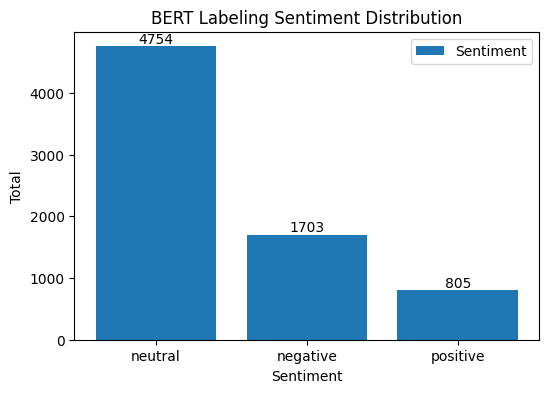

In [35]:
import matplotlib.pyplot as plt

# Hitung jumlah kemunculan setiap label sentimen
bert_counts = db_merge['BERT_Label'].value_counts()

# Membuat plot
plt.figure(figsize=(6, 4))
bars = plt.bar(bert_counts.index, bert_counts.values, label='Sentiment')

# Menambahkan label pada setiap batang
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(bar.get_height()), ha='center', fontsize=10)

# Menambahkan judul dan label
plt.title('BERT Labeling Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Total')
plt.legend()

# Menampilkan plot
plt.show()


In [36]:
db_merge['VADER_Label'].value_counts()

,count
VADER_Label,
neutral,6177
positive,797
negative,288


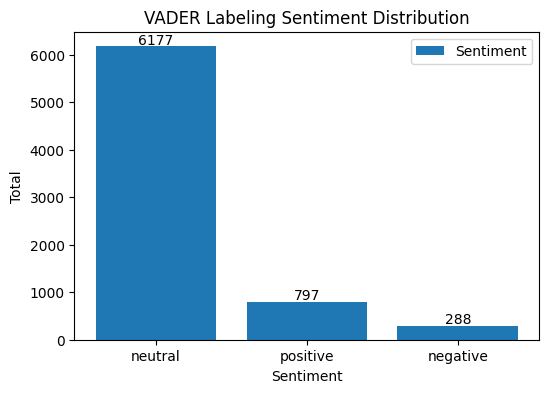

In [37]:
import matplotlib.pyplot as plt

# Hitung jumlah kemunculan setiap label sentimen
vader_counts = db_merge['VADER_Label'].value_counts()

# Membuat plot
plt.figure(figsize=(6, 4))
bars = plt.bar(vader_counts.index, vader_counts.values, label='Sentiment')

# Menambahkan label pada setiap batang
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(bar.get_height()), ha='center', fontsize=10)

# Menambahkan judul dan label
plt.title('VADER Labeling Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Total')
plt.legend()

# Menampilkan plot
plt.show()


## SAVE DATA DAN READ

In [50]:
# Tentukan nama file untuk menyimpan data
output_file = '/content/drive/MyDrive/Laporan_NLP/NLP/Data/Hasil/db_merge_with_sentiment_24apr.csv'

# Menyimpan DataFrame db_merge ke dalam file CSV
db_merge.to_csv(output_file, index=False)

print(f"Data berhasil disimpan ke {output_file}")

Data berhasil disimpan ke /content/drive/MyDrive/Laporan_NLP/NLP/Data/Hasil/db_merge_with_sentiment_24apr.csv


In [51]:
# Path file di Google Drive
file_path = '/content/drive/MyDrive/Laporan_NLP/NLP/Data/Hasil/db_merge_with_sentiment_24apr.csv'

# Membaca file CSV
db_merge = pd.read_csv(file_path)

# Menampilkan dimensi dan beberapa baris pertama data
print(f"Dimensi data: {db_merge.shape}")
db_merge.head()

Dimensi data: (7262, 10)


,username,in_reply_to_screen_name,full_text,Cleaned_Text,Tokenized_Text,Formalized_Text,Stopword_Removed_Text,Stemmed_Text,BERT_Label,VADER_Label
0,oravine_,oravine_,cuma yang nggak mengalami PTSD yang digunain buat perhitungan IQ. Ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting.,cuma yang nggak mengalami ptsd yang digunain buat perhitungan iq ini salah satu contoh yang nunjukin sampel yang digunain di sini berasal dari wilayah tertentu dengan kondisi sosial tertentu termasuk disebutin daerah yang terdampak defisiensi yodium cacingan atau stunting,"['cuma', 'yang', 'nggak', 'mengalami', 'ptsd', 'yang', 'digunain', 'buat', 'perhitungan', 'iq', 'ini', 'salah', 'satu', 'contoh', 'yang', 'nunjukin', 'sampel', 'yang', 'digunain', 'di', 'sini', 'berasal', 'dari', 'wilayah', 'tertentu', 'dengan', 'kondisi', 'sosial', 'tertentu', 'termasuk', 'disebutin', 'daerah', 'yang', 'terdampak', 'defisiensi', 'yodium', 'cacingan', 'atau', 'stunting']","['cuma', 'yang', 'tidak', 'mengalami', 'ptsd', 'yang', 'digunain', 'buat', 'perhitungan', 'iq', 'ini', 'salah', 'satu', 'contoh', 'yang', 'nunjukin', 'sampel', 'yang', 'digunain', 'di', 'sini', 'berasal', 'dari', 'wilayah', 'tertentu', 'dengan', 'kondisi', 'sosial', 'tertentu', 'termasuk', 'disebutin', 'daerah', 'yang', 'terdampak', 'defisiensi', 'yodium', 'cacingan', 'atau', 'stunting']",mengalami ptsd digunain perhitungan iq salah contoh nunjukin sampel digunain berasal wilayah kondisi sosial disebutin daerah terdampak defisiensi yodium cacingan stunting,"['alami', 'ptsd', 'digunain', 'hitung', 'iq', 'salah', 'contoh', 'nunjukin', 'sampel', 'digunain', 'asal', 'wilayah', 'kondisi', 'sosial', 'disebutin', 'daerah', 'dampak', 'defisiensi', 'yodium', 'cacing', 'stunting']",neutral,neutral
1,sebayu_94FM,NaN,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR) Kota Tegal bersama Kelurahan Tegalsari serta Puskesmas Tegal Barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting. Selengkapnya di https://t.co/VBeJ8wCaE2 #infotegal #kotategal #pemkottegal https://t.co/zgVjt1Hc78,dinas pekerjaan umum dan penataan ruang dpupr kota tegal bersama kelurahan tegalsari serta puskesmas tegal barat bersinergi dan berkolaborasi melalui inovasinya dalam menangani kasus stunting selengkapnya di infotegal kotategal pemkottegal,"['dinas', 'pekerjaan', 'umum', 'dan', 'penataan', 'ruang', 'dpupr', 'kota', 'tegal', 'bersama', 'kelurahan', 'tegalsari', 'serta', 'puskesmas', 'tegal', 'barat', 'bersinergi', 'dan', 'berkolaborasi', 'melalui', 'inovasinya', 'dalam', 'menangani', 'kasus', 'stunting', 'selengkapnya', 'di', 'infotegal', 'kotategal', 'pemkottegal']","['dinas', 'pekerjaan', 'umum', 'dan', 'penataan', 'ruang', 'dpupr', 'kota', 'tegal', 'bersama', 'kelurahan', 'tegalsari', 'serta', 'puskesmas', 'tegal', 'barat', 'bersinergi', 'dan', 'berkolaborasi', 'melalui', 'inovasinya', 'dalam', 'menangani', 'kasus', 'stunting', 'selengkapnya', 'di', 'infotegal', 'kotategal', 'pemkottegal']",dinas pekerjaan penataan ruang dpupr kota tegal kelurahan tegalsari puskesmas tegal barat bersinergi berkolaborasi inovasinya menangani stunting selengkapnya infotegal kotategal pemkottegal,"['dinas', 'kerja', 'tata', 'ruang', 'dpupr', 'kota', 'tegal', 'lurah', 'tegalsari', 'puskesmas', 'tegal', 'barat', 'sinergi', 'kolaborasi', 'inovasi', 'tangan', 'stunting', 'lengkap', 'infotegal', 'kotategal', 'pemkottegal']",neutral,neutral
2,raquellstep,ajengrizkyJ,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya. itu jg faktor tidak langsung. makanya kan aku blg cmiiw,ajengrizkyj bibahjenner tanyakanrl kak maaf bgt ya kalo salah tp yg aku sebut jg bukan ibunya yg stunting tp nnt si anaknya itu jg faktor tidak langsung makanya kan aku blg cmiiw,"['ajengrizkyj', 'bibahjenner', 'tanyakanrl', 'kak', 

In [52]:
# Tentukan nama file untuk menyimpan data
output_file = '/content/drive/MyDrive/Laporan_NLP/NLP/Data/Hasil/db_merge_with_sentiment_24apr_drop.csv'

# Menghapus baris dengan nilai kosong pada kolom in_reply_to_screen_name
db_merge_drop = db_merge.dropna(subset=['in_reply_to_screen_name'])

# Menyimpan DataFrame db_merge ke dalam file CSV
db_merge_drop.to_csv(output_file, index=False)

print(f"Data berhasil disimpan ke {output_file}")

Data berhasil disimpan ke /content/drive/MyDrive/Laporan_NLP/NLP/Data/Hasil/db_merge_with_sentiment_24apr_drop.csv


In [53]:
import pandas as pd

# Path file di Google Drive
file_path = '/content/drive/MyDrive/Laporan_NLP/NLP/Data/Hasil/db_merge_with_sentiment_24apr_drop.csv'

# Membaca file CSV
db_merge_drop = pd.read_csv(file_path)


# Menampilkan dimensi dan beberapa baris pertama data setelah pembersihan
print(f"Dimensi data setelah menghapus baris kosong: {db_merge_drop.shape}")
db_merge_drop.info()


Dimensi data setelah menghapus baris kosong: (2976, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   username                 2976 non-null   object
 1   in_reply_to_screen_name  2976 non-null   object
 2   full_text                2976 non-null   object
 3   Cleaned_Text             2976 non-null   object
 4   Tokenized_Text           2976 non-null   object
 5   Formalized_Text          2976 non-null   object
 6   Stopword_Removed_Text    2976 non-null   object
 7   Stemmed_Text             2976 non-null   object
 8   BERT_Label               2976 non-null   object
 9   VADER_Label              2976 non-null   object
dtypes: object(10)
memory usage: 232.6+ KB


### 10.Visualisasi Sentimen dengan WordCloud:

#### Visualisasi untuk hasil Pelabelan BERT

In [42]:
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Fungsi untuk membersihkan tanda kutip dan karakter lain
def clean_text(text):
    # Menghapus tanda kutip tunggal dan ganda
    text = re.sub(r"['’]", '', text)
    # Menghapus karakter selain huruf dan spasi
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    return text

# Pisahkan data berdasarkan BERT_Label
positive_tweets = db_merge[db_merge['BERT_Label'] == 'positive']['Stemmed_Text']
negative_tweets = db_merge[db_merge['BERT_Label'] == 'negative']['Stemmed_Text']
neutral_tweets = db_merge[db_merge['BERT_Label'] == 'neutral']['Stemmed_Text']

# Gabungkan teks untuk masing-masing kelas dengan memastikan setiap elemen adalah string
positive_text = ' '.join(positive_tweets.astype(str))
negative_text = ' '.join(negative_tweets.astype(str))
neutral_text = ' '.join(neutral_tweets.astype(str))

# Bersihkan teks dari tanda kutip dan karakter lainnya
positive_text_clean = clean_text(positive_text)
negative_text_clean = clean_text(negative_text)
neutral_text_clean = clean_text(neutral_text)

# Buat Wordcloud untuk setiap kelas
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_text_clean)
wordcloud_negative = WordCloud(width=800, height=400, background_color='white').generate(negative_text_clean)
wordcloud_neutral = WordCloud(width=800, height=400, background_color='white').generate(neutral_text_clean)

# Tampilkan Wordcloud untuk masing-masing kategori secara terpisah

# Wordcloud untuk Positive Sentiment
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.title('Wordcloud - Positive Sentiment')
plt.axis('off')
plt.show()

# Wordcloud untuk Negative Sentiment
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.title('Wordcloud - Negative Sentiment')
plt.axis('off')
plt.show()

# Wordcloud untuk Neutral Sentiment
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud_neutral, interpolation='bilinear')
plt.title('Wordcloud - Neutral Sentiment')
plt.axis('off')
plt.show()


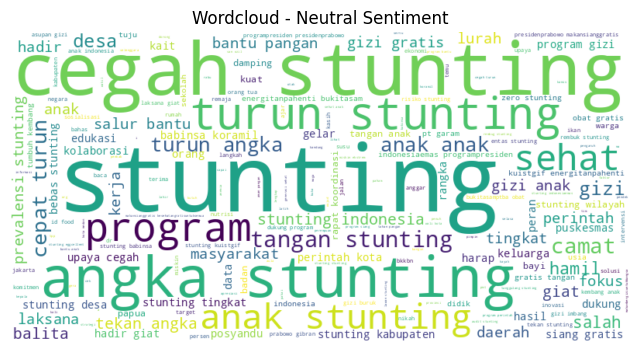

In [43]:
import re
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Fungsi untuk membersihkan tanda kutip dan karakter lain
def clean_text(text):
    # Menghapus tanda kutip tunggal dan ganda
    text = re.sub(r"['’]", '', text)
    # Menghapus karakter selain huruf dan spasi
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    return text

# # Daftar stopwords kustom yang akan dihapus
# custom_stopwords = set(STOPWORDS).union({
#     "yg", "dg", "rt", "dgn", "ny", "d", "ga", "klo", "kalo", "amp", "biar",
#     "bikin", "bilang", "gak", "g", "krn", "nya", "sih", "si", "tau", "tdk",
#     "utk", "ya", "jd", "jgn", "sdh", "aja", "n", "t", "nyg", "hehe", "pen",
#     "u", "loh", "yah", "gmn", "ttp", "dk", "kn", "dlm", "kl", "b", "dan",
#     "yang", "di", "dengan", "dari", "kamu", "jadi", "ke", "itu", "ini",
#     "saja", "juga", "lagi", "ada", "untuk"
# })

# Pisahkan data berdasarkan BERT_Label
positive_tweets = db_merge[db_merge['BERT_Label'] == 'positive']['Stemmed_Text']
negative_tweets = db_merge[db_merge['BERT_Label'] == 'negative']['Stemmed_Text']
neutral_tweets = db_merge[db_merge['BERT_Label'] == 'neutral']['Stemmed_Text']

# Gabungkan teks untuk masing-masing kelas dengan memastikan setiap elemen adalah string
positive_text = ' '.join(positive_tweets.astype(str))
negative_text = ' '.join(negative_tweets.astype(str))
neutral_text = ' '.join(neutral_tweets.astype(str))

# Bersihkan teks dari tanda kutip dan karakter lainnya
positive_text_clean = clean_text(positive_text)
negative_text_clean = clean_text(negative_text)
neutral_text_clean = clean_text(neutral_text)

# Buat Wordcloud untuk setiap kelas dengan stopwords
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(positive_text_clean)
wordcloud_negative = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(negative_text_clean)
wordcloud_neutral = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(neutral_text_clean)

# Tampilkan Wordcloud untuk masing-masing kategori secara terpisah

# Wordcloud untuk Positive Sentiment
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.title('Wordcloud - Positive Sentiment')
plt.axis('off')
plt.show()

# Wordcloud untuk Negative Sentiment
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.title('Wordcloud - Negative Sentiment')
plt.axis('off')
plt.show()

# Wordcloud untuk Neutral Sentiment
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud_neutral, interpolation='bilinear')
plt.title('Wordcloud - Neutral Sentiment')
plt.axis('off')
plt.show()


#### Visualisasi untuk hasil Pelabelan VADER

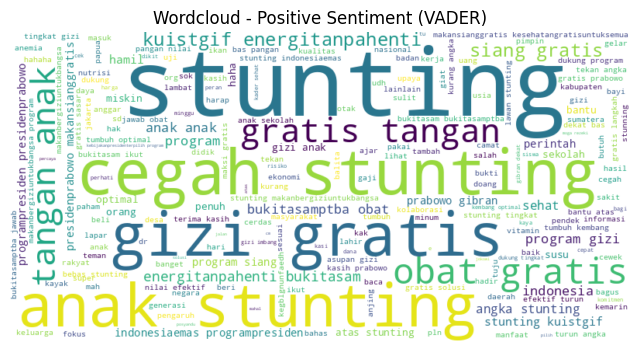

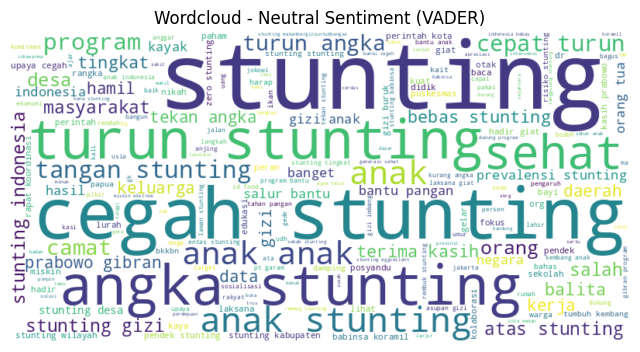

In [44]:
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Fungsi untuk membersihkan tanda kutip dan karakter lain
def clean_text(text):
    # Menghapus tanda kutip tunggal dan ganda
    text = re.sub(r"['’]", '', text)
    # Menghapus karakter selain huruf dan spasi
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    return text

# Pisahkan data berdasarkan VADER_Label
positive_tweets_vader = db_merge[db_merge['VADER_Label'] == 'positive']['Stemmed_Text']
negative_tweets_vader = db_merge[db_merge['VADER_Label'] == 'negative']['Stemmed_Text']
neutral_tweets_vader = db_merge[db_merge['VADER_Label'] == 'neutral']['Stemmed_Text']

# Gabungkan teks untuk masing-masing kelas dengan memastikan setiap elemen adalah string
positive_text_vader = ' '.join(positive_tweets_vader.astype(str))
negative_text_vader = ' '.join(negative_tweets_vader.astype(str))
neutral_text_vader = ' '.join(neutral_tweets_vader.astype(str))

# Bersihkan teks dari tanda kutip dan karakter lainnya
positive_text_clean_vader = clean_text(positive_text_vader)
negative_text_clean_vader = clean_text(negative_text_vader)
neutral_text_clean_vader = clean_text(neutral_text_vader)

# Buat Wordcloud untuk setiap kelas
wordcloud_positive_vader = WordCloud(width=800, height=400, background_color='white').generate(positive_text_clean_vader)
wordcloud_negative_vader = WordCloud(width=800, height=400, background_color='white').generate(negative_text_clean_vader)
wordcloud_neutral_vader = WordCloud(width=800, height=400, background_color='white').generate(neutral_text_clean_vader)

# Tampilkan Wordcloud untuk masing-masing kategori secara terpisah

# Wordcloud untuk Positive Sentiment
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud_positive_vader, interpolation='bilinear')
plt.title('Wordcloud - Positive Sentiment (VADER)')
plt.axis('off')
plt.show()

# Wordcloud untuk Negative Sentiment
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud_negative_vader, interpolation='bilinear')
plt.title('Wordcloud - Negative Sentiment (VADER)')
plt.axis('off')
plt.show()

# Wordcloud untuk Neutral Sentiment
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud_neutral_vader, interpolation='bilinear')
plt.title('Wordcloud - Neutral Sentiment (VADER)')
plt.axis('off')
plt.show()


In [45]:
import re
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Fungsi untuk membersihkan tanda kutip dan karakter lain
def clean_text(text):
    # Menghapus tanda kutip tunggal dan ganda
    text = re.sub(r"['’]", '', text)
    # Menghapus karakter selain huruf dan spasi
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    return text

# Daftar stopwords kustom yang akan dihapus
# custom_stopwords = set(STOPWORDS).union({
#     "yg", "dg", "rt", "dgn", "ny", "d", "ga", "klo", "kalo", "amp", "biar",
#     "bikin", "bilang", "gak", "g", "krn", "nya", "sih", "si", "tau", "tdk",
#     "utk", "ya", "jd", "jgn", "sdh", "aja", "n", "t", "nyg", "hehe", "pen",
#     "u", "loh", "yah", "gmn", "ttp", "dk", "kn", "dlm", "kl", "b", "dan",
#     "yang", "di", "dengan", "dari", "kamu", "jadi", "ke", "itu", "ini",
#     "saja", "juga", "lagi", "ada", "untuk"
# })

# Pisahkan data berdasarkan VADER_Label
positive_tweets_vader = db_merge[db_merge['VADER_Label'] == 'positive']['Stemmed_Text']
negative_tweets_vader = db_merge[db_merge['VADER_Label'] == 'negative']['Stemmed_Text']
neutral_tweets_vader = db_merge[db_merge['VADER_Label'] == 'neutral']['Stemmed_Text']

# Gabungkan teks untuk masing-masing kelas dengan memastikan setiap elemen adalah string
positive_text_vader = ' '.join(positive_tweets_vader.astype(str))
negative_text_vader = ' '.join(negative_tweets_vader.astype(str))
neutral_text_vader = ' '.join(neutral_tweets_vader.astype(str))

# Bersihkan teks dari tanda kutip dan karakter lainnya
positive_text_clean_vader = clean_text(positive_text_vader)
negative_text_clean_vader = clean_text(negative_text_vader)
neutral_text_clean_vader = clean_text(neutral_text_vader)

# Buat Wordcloud untuk setiap kelas dengan stopwords
wordcloud_positive_vader = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(positive_text_clean_vader)
wordcloud_negative_vader = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(negative_text_clean_vader)
wordcloud_neutral_vader = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(neutral_text_clean_vader)

# Tampilkan Wordcloud untuk masing-masing kategori secara terpisah

# Wordcloud untuk Positive Sentiment (VADER)
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud_positive_vader, interpolation='bilinear')
plt.title('Wordcloud - Positive Sentiment (VADER)')
plt.axis('off')
plt.show()

# Wordcloud untuk Negative Sentiment (VADER)
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud_negative_vader, interpolation='bilinear')
plt.title('Wordcloud - Negative Sentiment (VADER)')
plt.axis('off')
plt.show()

# Wordcloud untuk Neutral Sentiment (VADER)
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud_neutral_vader, interpolation='bilinear')
plt.title('Wordcloud - Neutral Sentiment (VADER)')
plt.axis('off')
plt.show()


#### Visualisasi Lainnya

In [ ]:
# === AUTO-GENERATED THUMBNAIL EXPORT ===
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os

# Find all existing figure axes
figures = [plt.figure(i) for i in plt.get_fignums()]
if figures:
    fig = figures[-1]  # Use last figure
else:
    # Create a summary figure from available data
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.text(0.5, 0.5, 'Project Visualization', fontsize=24, 
            ha='center', va='center', transform=ax.transAxes,
            fontweight='bold', color='#2d3436')
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('#f8f9fa')
    ax.axis('off')

thumbnail_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'thumbnail.png')
fig.savefig(thumbnail_path, dpi=150, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print(f"✅ Thumbnail saved: {thumbnail_path}")
plt.show()
